In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, KernelPCA
import umap
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_theme(style="whitegrid")


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Load the Data
print("Loading data...")
df_meth = pd.read_parquet('../data/processed/methylation_kirc_train.parquet')
df_clin = pd.read_csv('../data/processed/clinical_kirc_train_clustered_umap.csv')


Loading data...


In [3]:
# 2. Align the Metadata
print("Aligning clinical data with methylation data...")
df_clin.set_index('sample', inplace=True)
df_clin = df_clin.reindex(df_meth.index)

# Define categorical and continuous columns separately
categorical_cols = [
    'tissue_type.samples', 
    'kmeans_umap_2_k2',
    'kmeans_umap_3_k2',
    'kmeans_raw_k2',
    'hierarchical_umap_2_k2',
    'hierarchical_umap_3_k2',
    'hierarchical_raw_k2',
    'gmm_umap_2_k2',
    'gmm_umap_3_k2',
    'gmm_umap_opt_k2'
]

# Process Categorical Columns: Fill missing with 'Unknown'
for col in categorical_cols:
    df_clin[col] = df_clin[col].fillna('Unknown')

# Combine lists for the plotting loop
all_cols_to_plot = categorical_cols


Aligning clinical data with methylation data...


Imputing missing values...
Scaling data...
Running PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

Running UMAP...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting results...


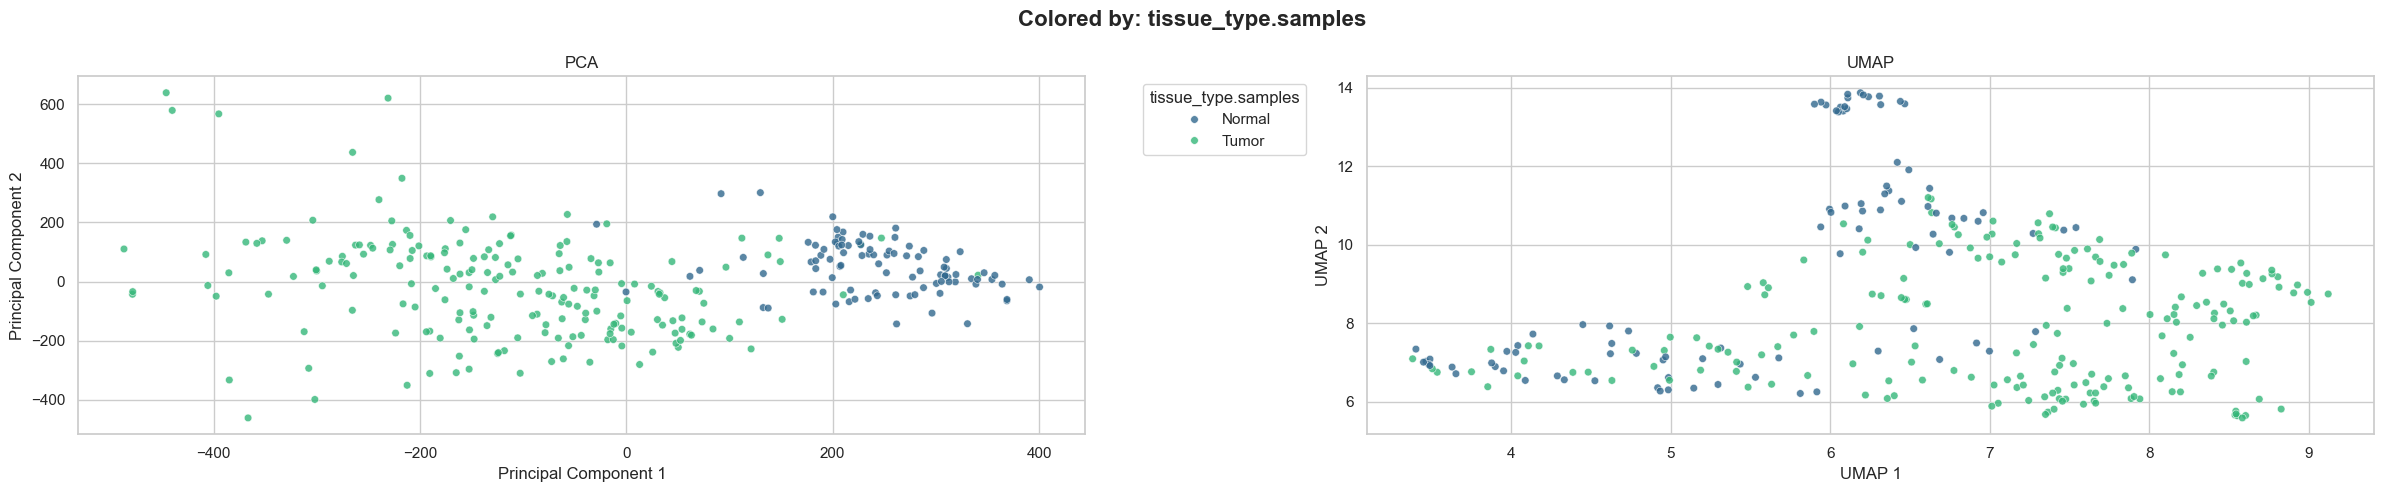

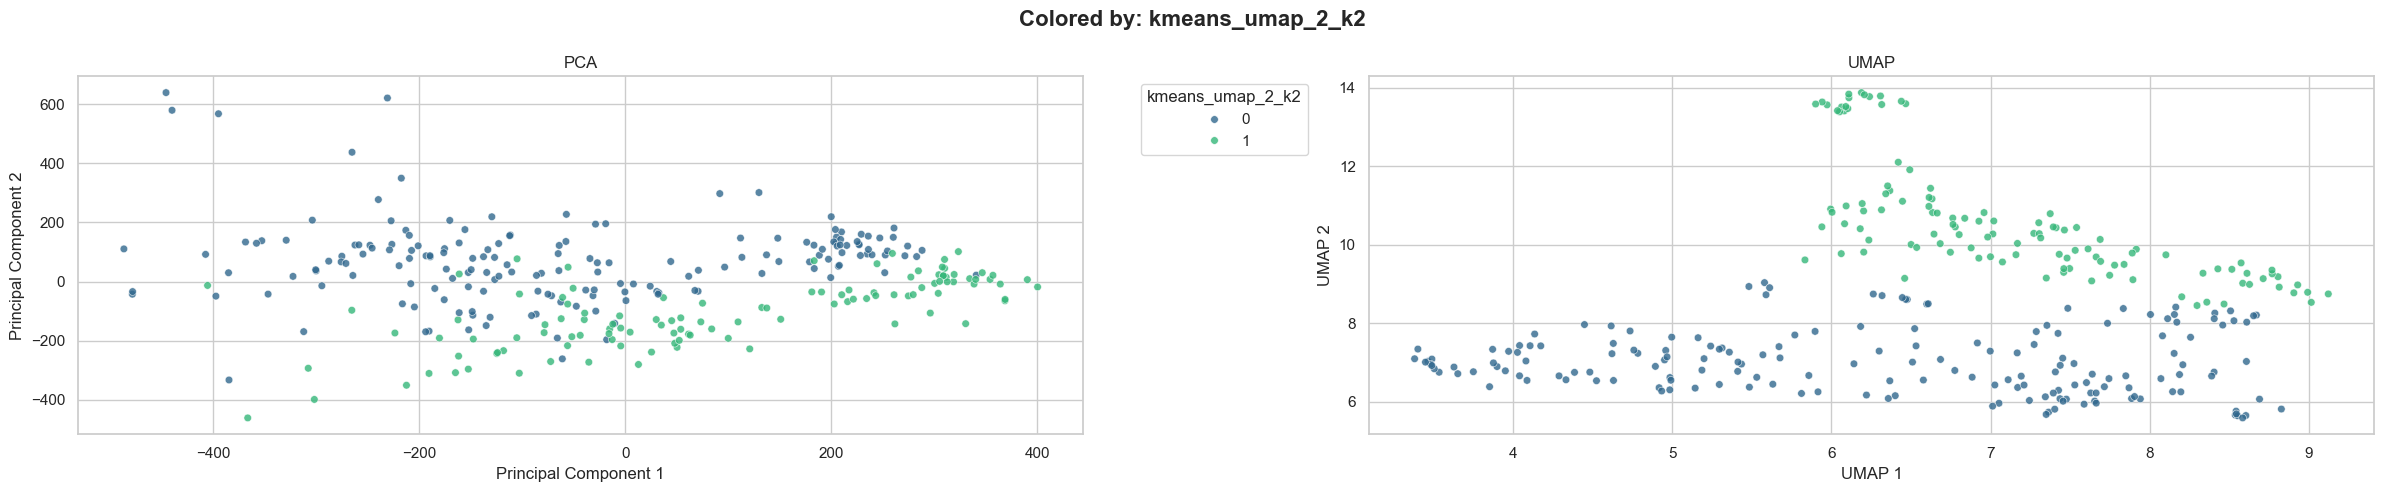

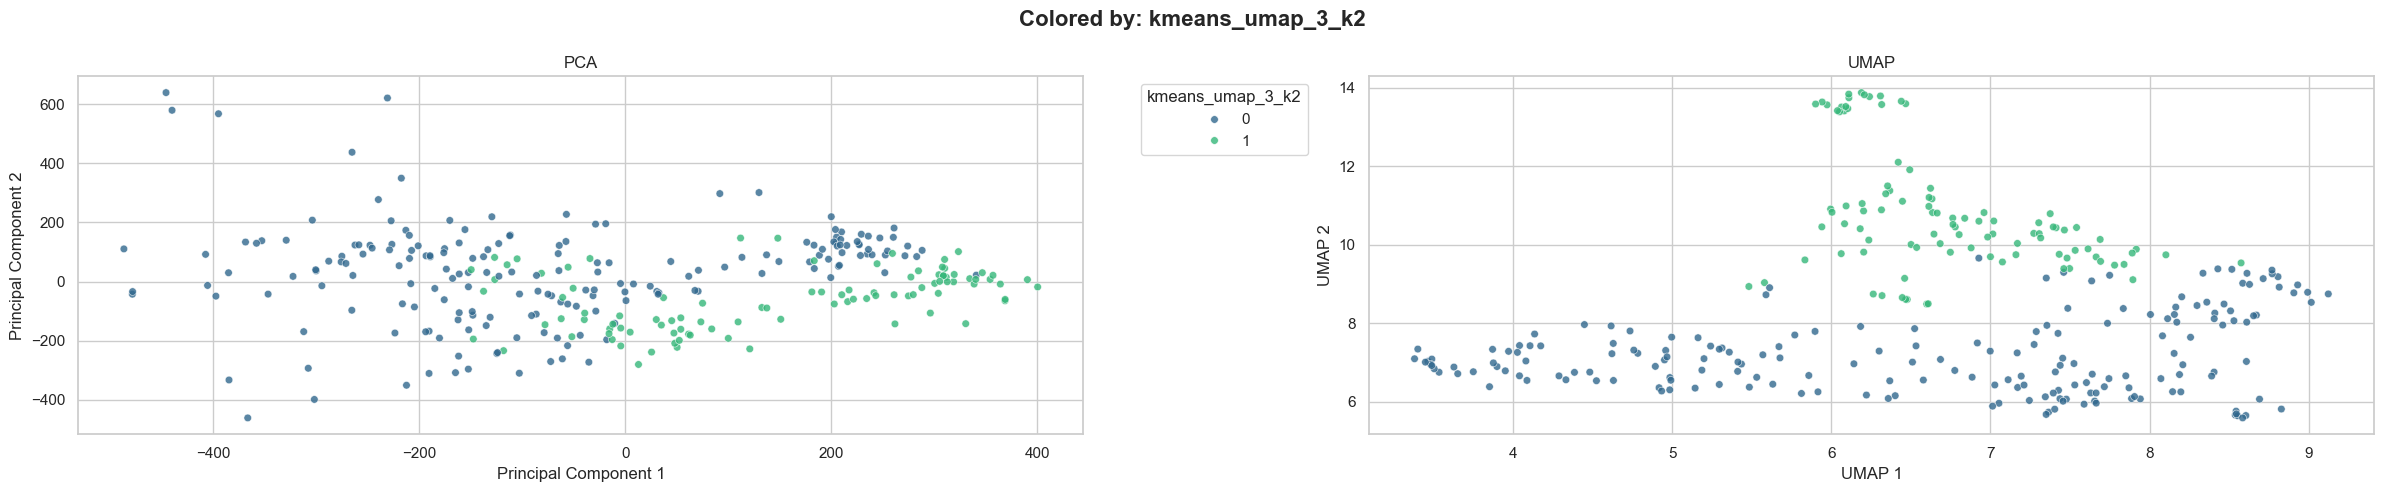

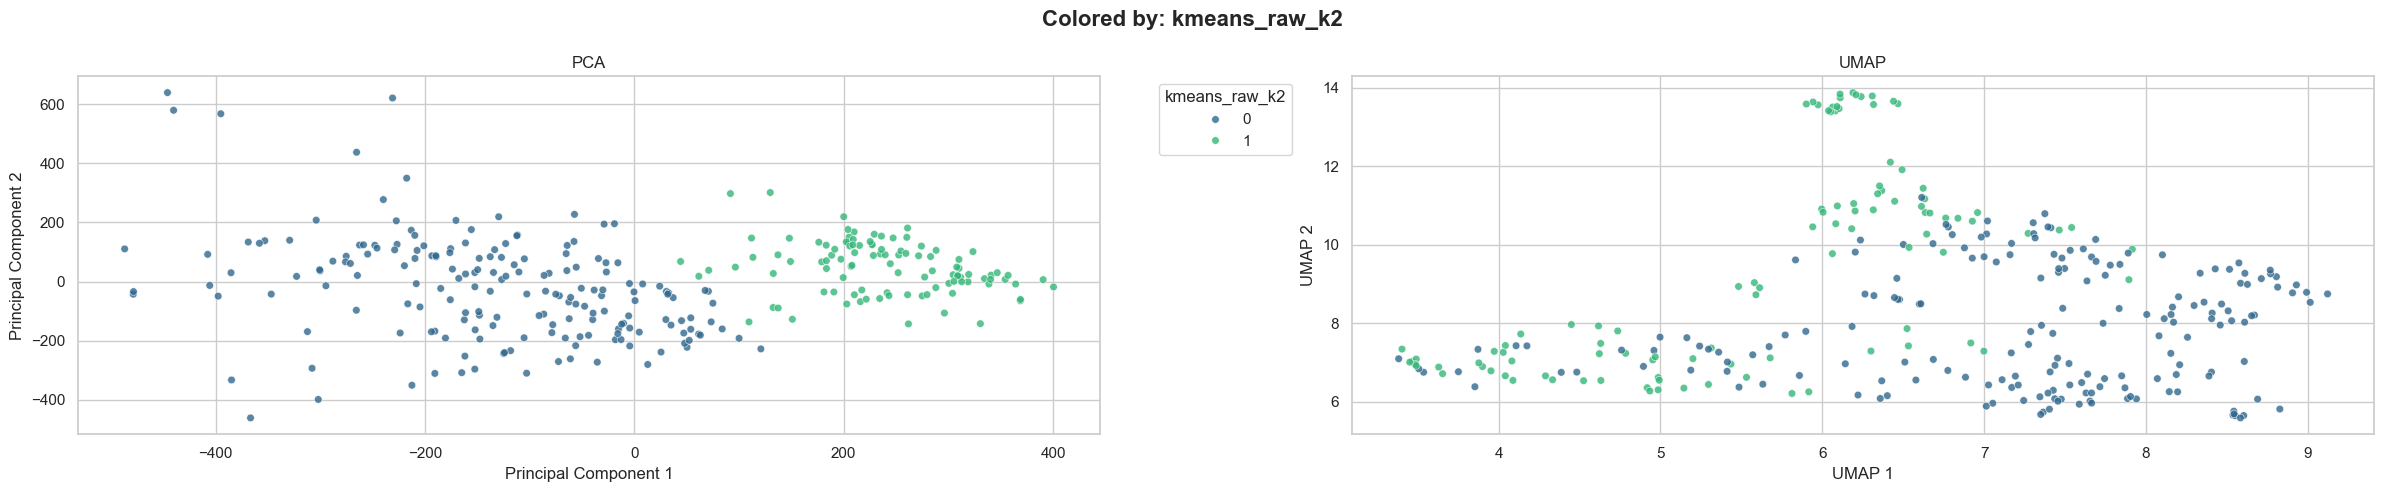

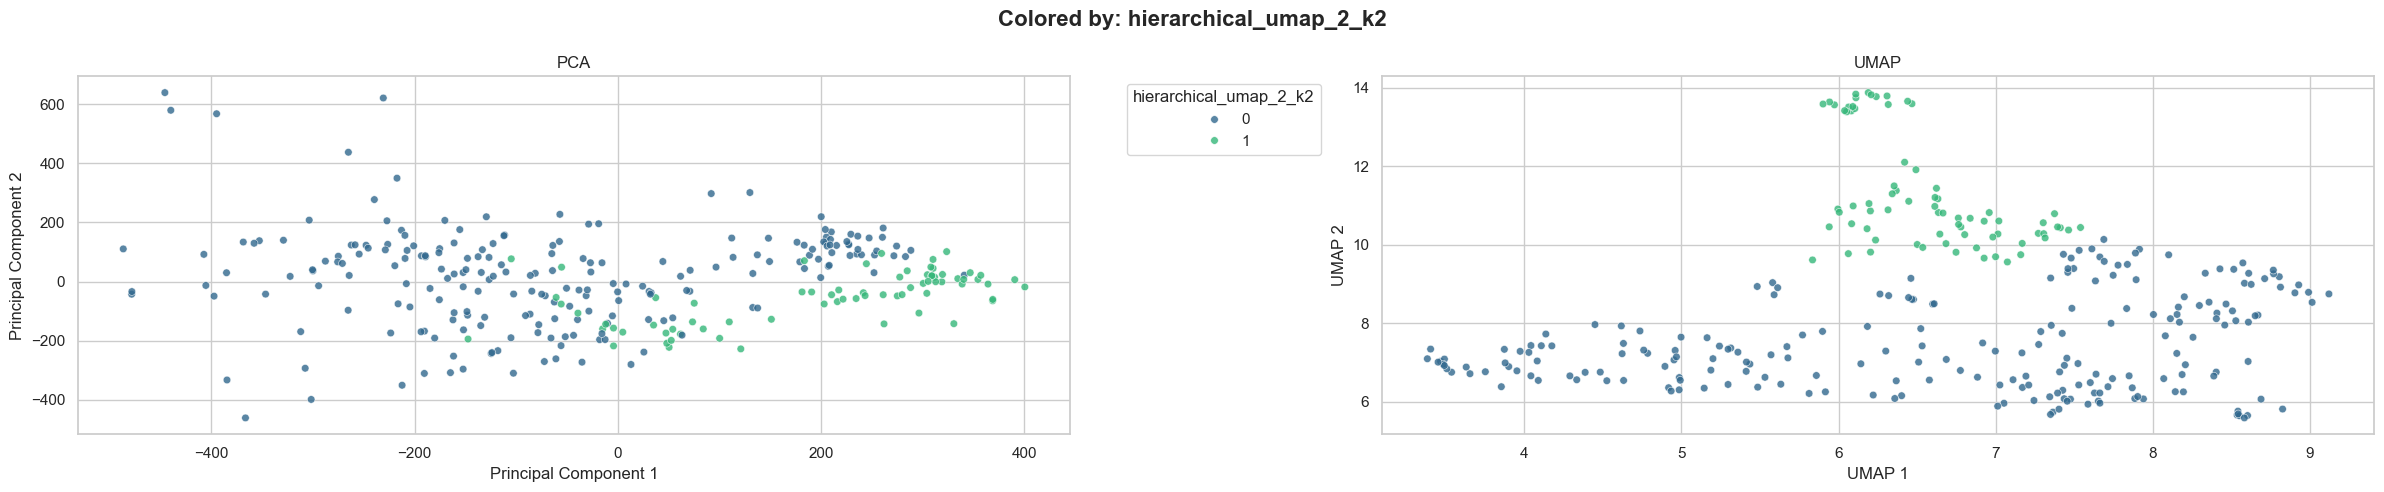

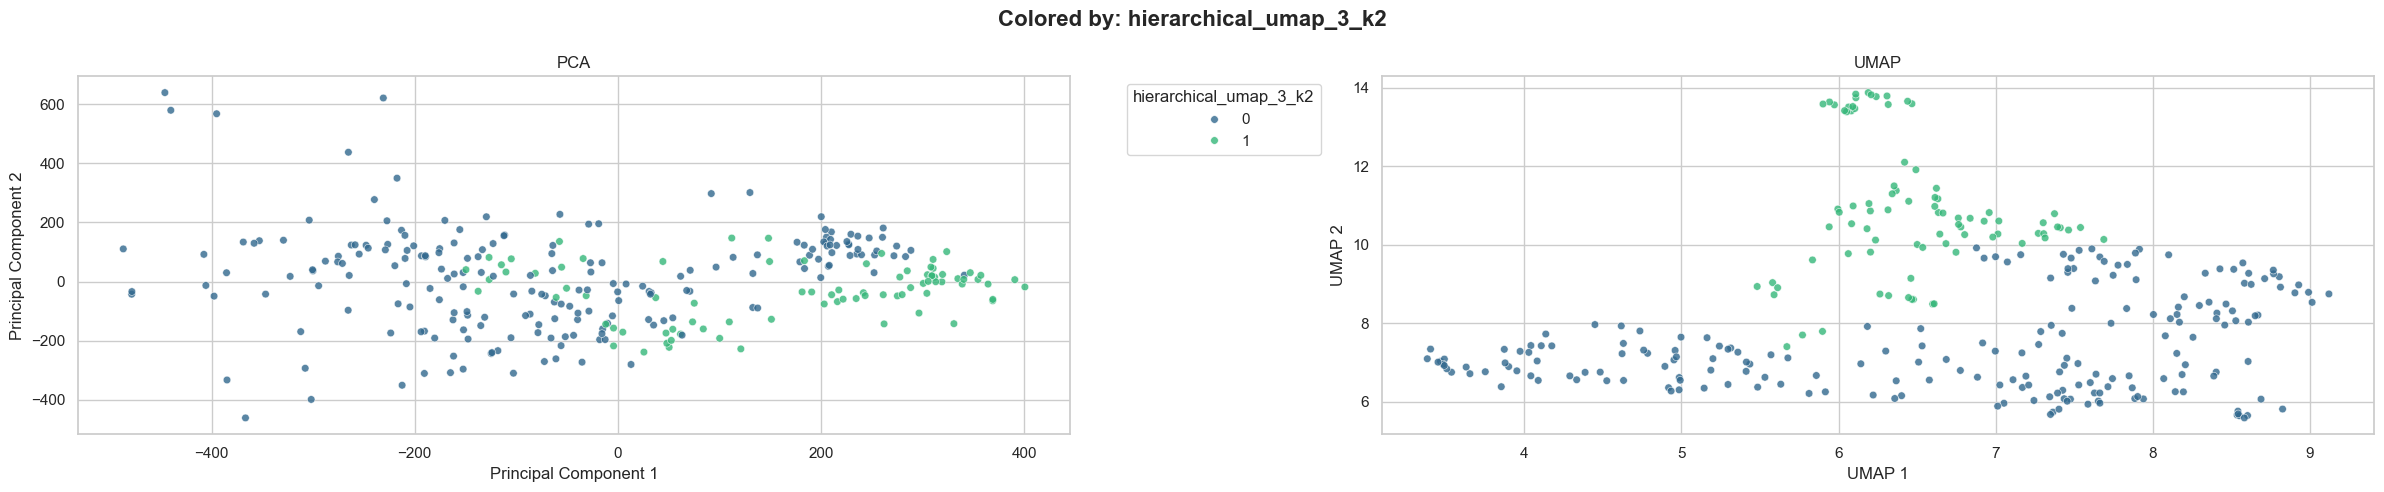

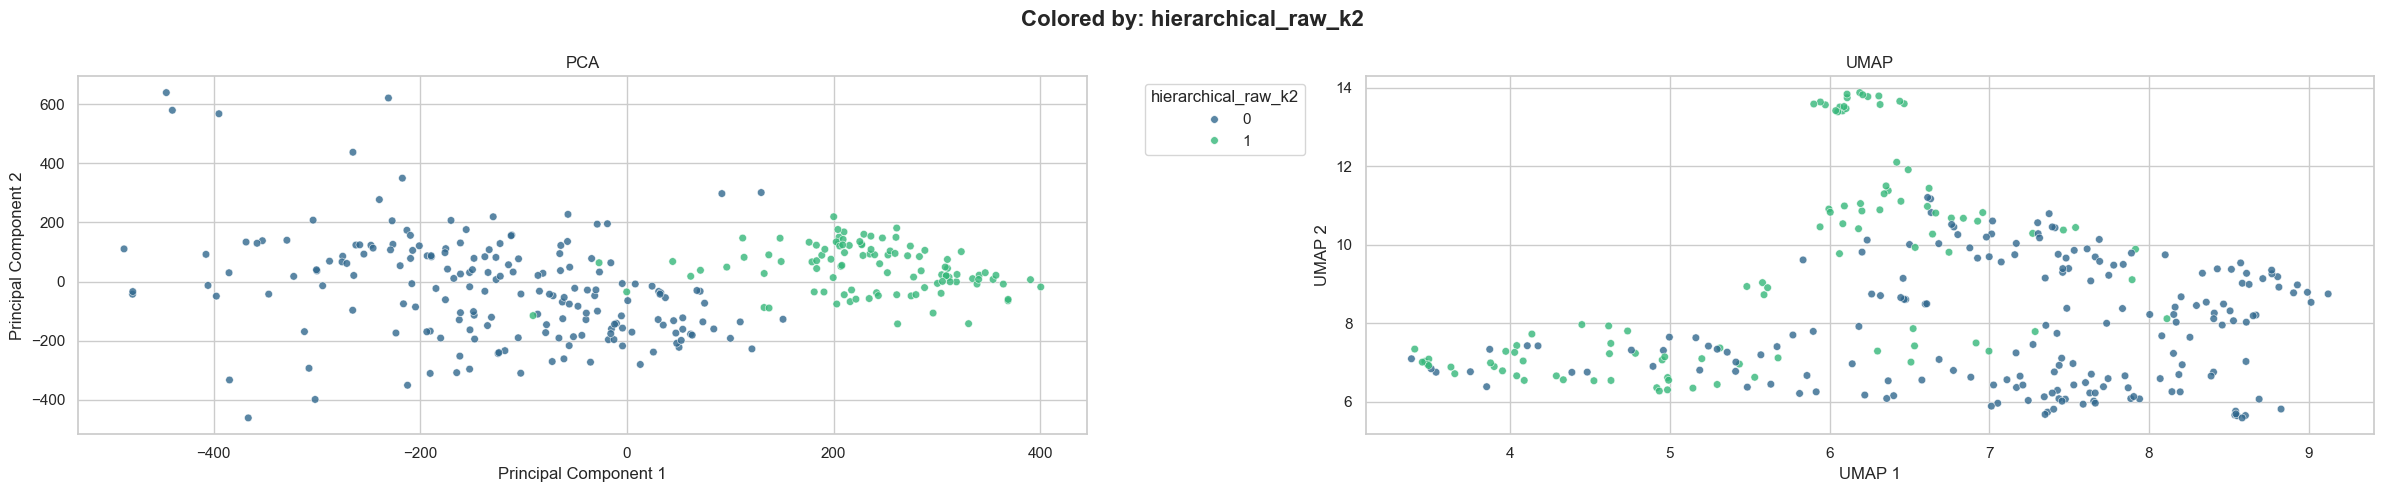

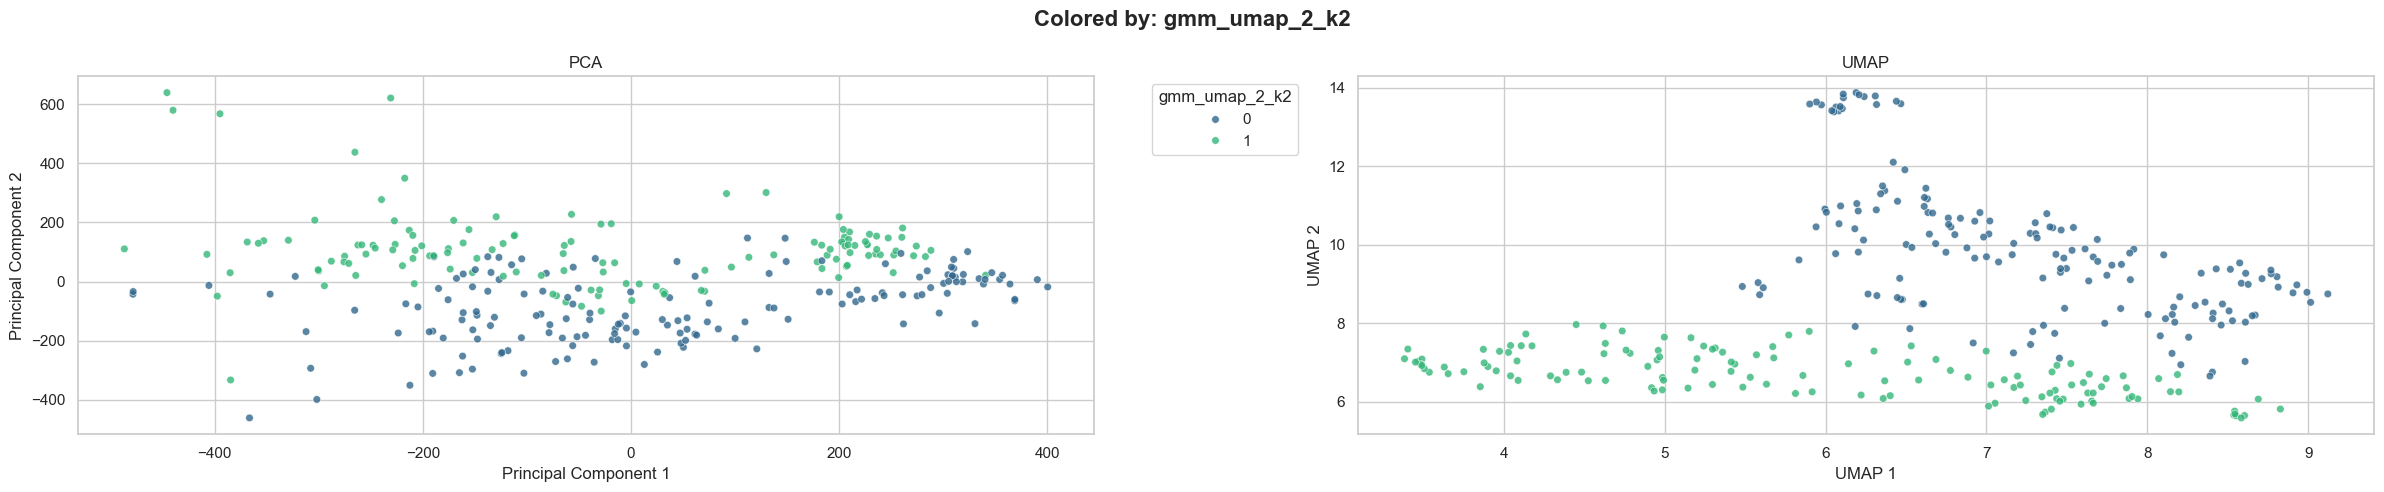

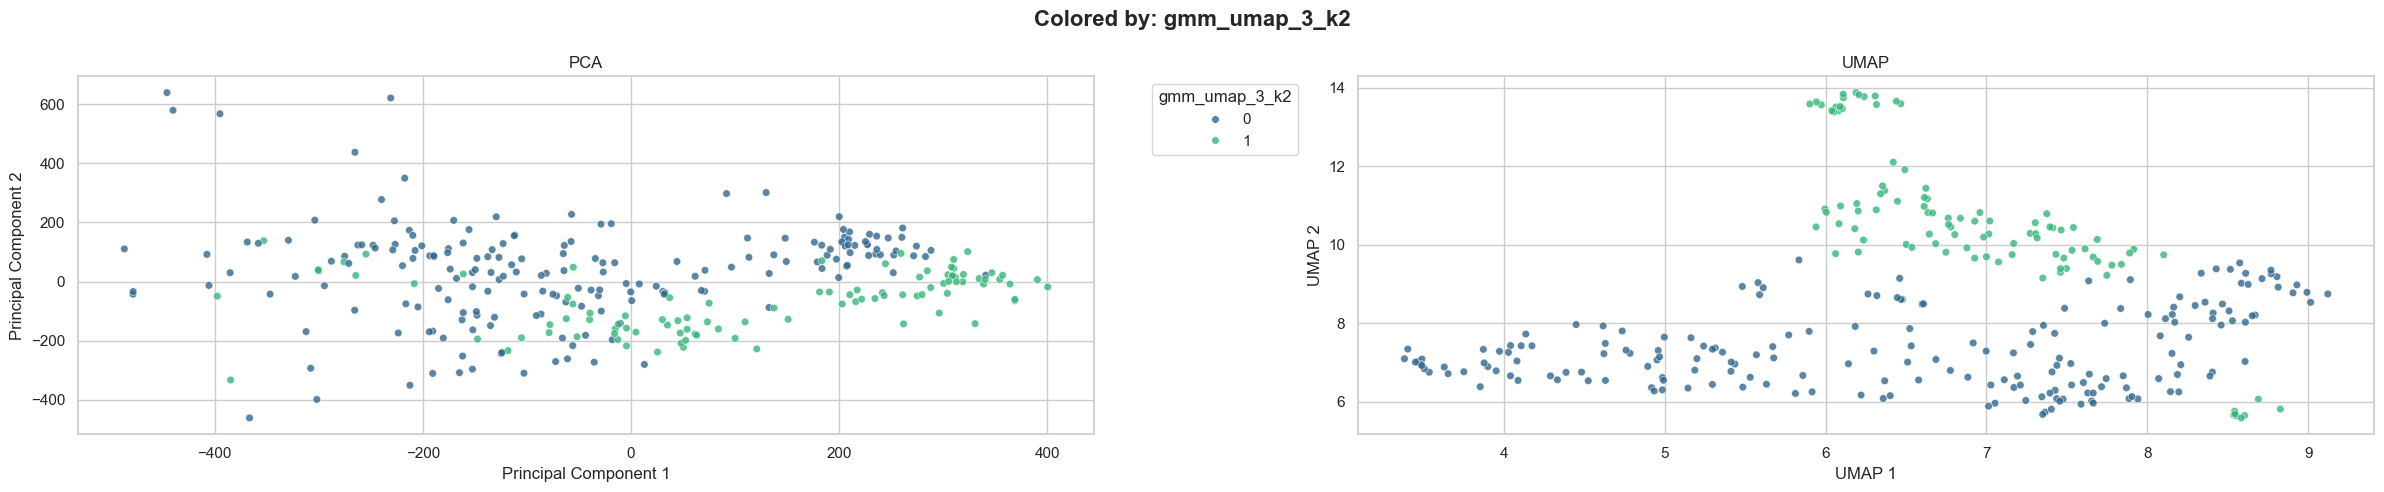

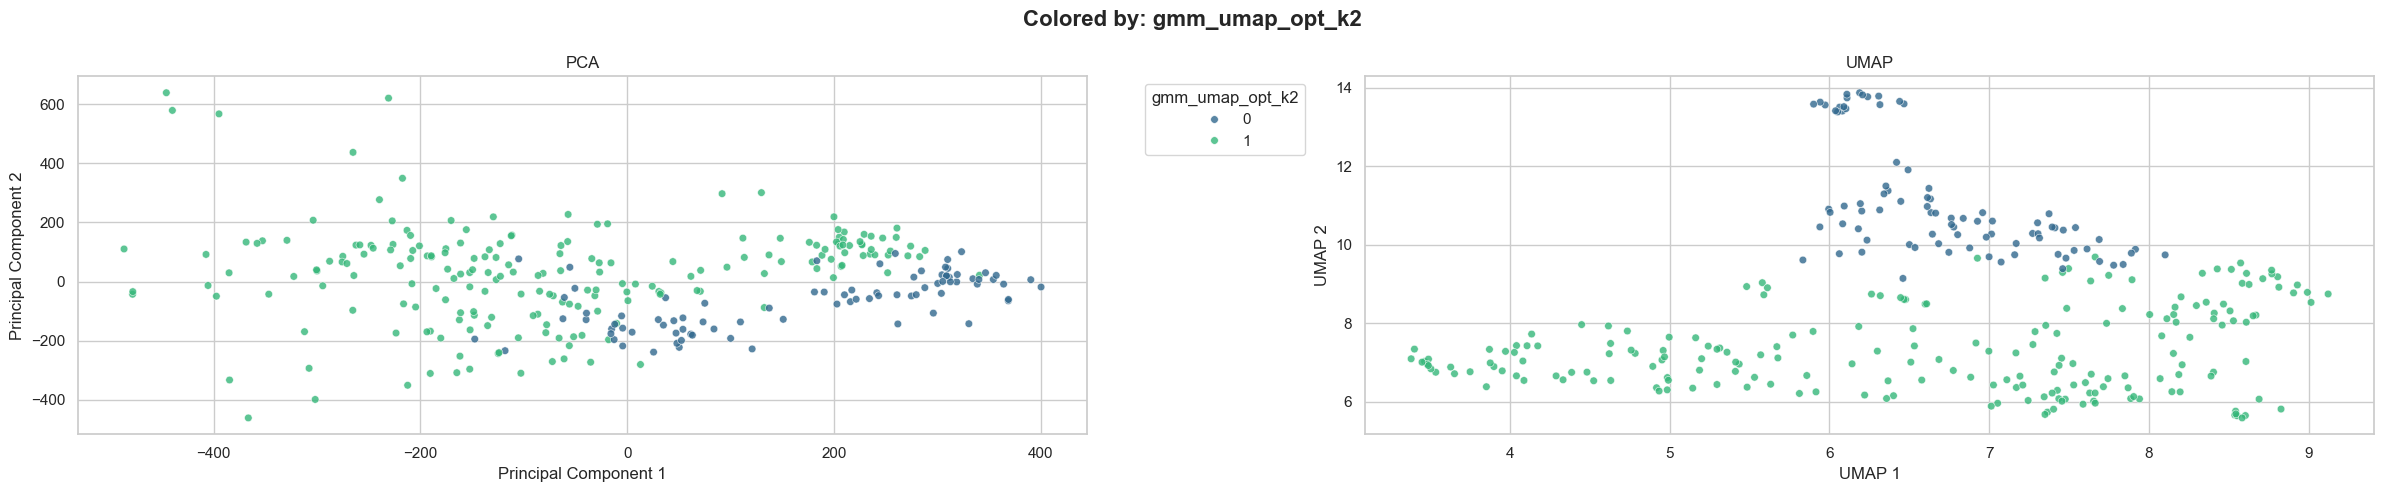

In [4]:


# 3. Preprocessing
print("Imputing missing values...")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df_meth)

print("Scaling data...")
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed) 

# 4. Dimensionality Reduction 
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X)


# 5. Visualization Loop
print("Plotting results...")

for col in all_cols_to_plot:
    color_labels = df_clin[col]
    
    # Expanded grid to 1x4 and increased figure width to 24 to accommodate t-SNE
    fig, axes = plt.subplots(1, 2, figsize=(24, 5))
    fig.suptitle(f'Colored by: {col}', fontsize=16, fontweight='bold')
    
    # Plot PCA
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1], 
        hue=color_labels, palette="viridis",
        alpha=0.8, s=30, ax=axes[0]
    )
    axes[0].set_title('PCA')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    
    # Move legend outside the first plot (you could also move it to the far right)
    sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.05, 1))

    # Plot UMAP
    sns.scatterplot(
        x=X_umap[:, 0], y=X_umap[:, 1], 
        hue=color_labels, palette="viridis",
        alpha=0.8, s=30, ax=axes[1], legend=False 
    )
    axes[1].set_title('UMAP')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')


    plt.tight_layout()
    plt.show()

In [5]:
# # 4. Dimensionality Reduction (Updated for 3D)
# print("Running PCA...")
# pca = PCA(n_components=3)
# X_pca = pca.fit_transform(X)

# print("Running Kernel PCA...")
# # Keep your gamma tuning in mind!
# kpca = KernelPCA(n_components=3, kernel='rbf', gamma=0.01, fit_inverse_transform=False, n_jobs=-1)
# X_kpca = kpca.fit_transform(X)

# print("Running UMAP...")
# reducer = umap.UMAP(n_components=3, random_state=42, n_jobs=-1)
# X_umap = reducer.fit_transform(X)

# # 5. Visualization Loop (Updated for 3D)
# print("Plotting results in 3D...")

# for col in all_cols_to_plot:
#     color_labels = df_clin[col]
#     is_continuous = col in continuous_cols
    
#     fig = plt.figure(figsize=(20, 6))
#     fig.suptitle(f'Colored by: {col}', fontsize=16, fontweight='bold')
    
#     # Initialize 3D axes
#     ax1 = fig.add_subplot(131, projection='3d')
#     ax2 = fig.add_subplot(132, projection='3d')
#     ax3 = fig.add_subplot(133, projection='3d')
    
#     if is_continuous:
#         # Plot continuous data using a colormap
#         p1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=color_labels, cmap='viridis', alpha=0.8, s=20)
#         ax2.scatter(X_kpca[:, 0], X_kpca[:, 1], X_kpca[:, 2], c=color_labels, cmap='viridis', alpha=0.8, s=20)
#         ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=color_labels, cmap='viridis', alpha=0.8, s=20)
        
#         # Add a colorbar for the continuous variable
#         fig.colorbar(p1, ax=[ax1, ax2, ax3], shrink=0.6, label=col)
        
#     else:
#         # Plot categorical data by looping through unique labels to build a legend
#         unique_labels = color_labels.unique()
#         palette = sns.color_palette("husl", len(unique_labels)) # Generate distinct colors
        
#         for i, label in enumerate(unique_labels):
#             idx = color_labels == label
            
#             ax1.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2], label=label, color=palette[i], alpha=0.8, s=20)
#             ax2.scatter(X_kpca[idx, 0], X_kpca[idx, 1], X_kpca[idx, 2], label=label, color=palette[i], alpha=0.8, s=20)
#             ax3.scatter(X_umap[idx, 0], X_umap[idx, 1], X_umap[idx, 2], label=label, color=palette[i], alpha=0.8, s=20)
        
#         # Add legend to the first plot (PCA), placed slightly outside
#         ax1.legend(loc='upper left', bbox_to_anchor=(1.1, 1), fontsize='small', title=col)

#     # Set Titles and Axis Labels
#     ax1.set_title('PCA')
#     ax1.set_xlabel('PC 1')
#     ax1.set_ylabel('PC 2')
#     ax1.set_zlabel('PC 3')
    
#     ax2.set_title('Kernel PCA (RBF)')
#     ax2.set_xlabel('Component 1')
#     ax2.set_ylabel('Component 2')
#     ax2.set_zlabel('Component 3')

#     ax3.set_title('UMAP')
#     ax3.set_xlabel('UMAP 1')
#     ax3.set_ylabel('UMAP 2')
#     ax3.set_zlabel('UMAP 3')

#     # Adjust layout to prevent overlap, especially with the 3D axes and legends
#     plt.tight_layout()
#     plt.show()